In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import os 
import glob

Loading each country's cleaned CSV and concatenating into a single DataFrame.

In [ ]:
# Load all cleaned country files
files = (glob.glob("C:\\Climate_data\\data\\ethiopia_clean.csv") 
+ glob.glob("C:\\Climate_data\\data\\kenya_clean.csv")
+ glob.glob("C:\\Climate_data\\data\\nigeria_clean.csv") 
+ glob.glob("C:\\Climate_data\\data\\sudan_clean.csv")
+ glob.glob("C:\\Climate_data\\data\\tanzania_clean.csv"))

dfs = []

for file in files:
    df = pd.read_csv(file)
    
    # Extract country name from filename
    country = os.path.basename(file).replace("_clean.csv", "")
    df["country"] = country
    
    # Parse date
    df["Date"] = pd.to_datetime(df["Date"])
    
    dfs.append(df)

# Combine into single DataFrame
data = pd.concat(dfs, ignore_index=True)

# Create time features
data["year"] = data["Date"].dt.year
data["month"] = data["Date"].dt.month

In [ ]:
print(t2m_summary)
print(precip_summary)
print(heat_total)
print(dry_total)

    country       mean  median       std
0  ethiopia  16.069557   16.04  1.897073
1     kenya  20.427811   20.36  1.440936
2   nigeria  26.657275   26.82  1.123251
3     sudan  28.759878   29.16  4.681542
4  tanzania  26.802238   26.99  1.325497
    country      mean  median       std
0  ethiopia  3.634680    0.82  6.289571
1     kenya  1.468520    0.38  3.180533
2   nigeria  4.214940    1.84  7.267329
3     sudan  0.644032    0.00  3.058028
4  tanzania  3.739403    0.64  8.004735
  country  extreme_heat_days
0   sudan               2693
    country  dry_days
0  ethiopia      2160
1     kenya      2830
2   nigeria      1594
3     sudan      3695
4  tanzania      2303


In [251]:
print(df.shape)
df.head()

(4107, 16)


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month,country
0,2015,2,27.59,29.99,25.92,4.07,3.40,79.63,4.48,5.28,100.52,18.31,Tanzania,2015-01-02,1,tanzania
1,2015,3,27.47,29.29,26.25,3.04,7.17,80.02,4.91,5.99,100.56,18.30,Tanzania,2015-01-03,1,tanzania
2,2015,4,27.28,29.17,25.96,3.21,16.07,81.78,4.88,6.07,100.47,18.52,Tanzania,2015-01-04,1,tanzania
3,2015,5,26.68,27.83,25.84,1.99,18.83,82.99,4.17,5.98,100.43,18.16,Tanzania,2015-01-05,1,tanzania
4,2015,6,27.27,29.33,25.71,3.62,7.59,81.89,4.63,5.84,100.50,18.50,Tanzania,2015-01-06,1,tanzania


In [252]:
df.tail()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month,country
4102,2026,86,27.63,30.65,25.66,4.99,2.96,77.48,1.57,2.40,100.73,17.72,Tanzania,2026-03-27,3,tanzania
4103,2026,87,27.51,31.23,24.84,6.39,1.65,77.72,1.36,1.79,100.61,17.59,Tanzania,2026-03-28,3,tanzania
4104,2026,88,27.74,31.21,25.33,5.88,1.28,77.35,1.53,2.01,100.42,17.81,Tanzania,2026-03-29,3,tanzania
4105,2026,89,27.83,31.29,25.31,5.98,0.92,76.50,1.64,2.15,100.43,17.72,Tanzania,2026-03-30,3,tanzania
4106,2026,90,28.14,31.55,26.06,5.49,0.83,74.46,1.35,1.90,100.47,17.56,Tanzania,2026-03-31,3,tanzania


In [253]:
print("An overview of the dataset: a random sample of 5 rows")
df.sample(5)

An overview of the dataset: a random sample of 5 rows


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month,country
2575,2022,20,27.13,28.46,26.16,2.30,22.61,85.00,3.82,5.05,100.48,19.11,Tanzania,2022-01-20,1,tanzania
2179,2020,355,28.29,30.99,26.13,4.86,0.94,73.66,2.74,3.63,100.57,17.57,Tanzania,2020-12-20,12,tanzania
2433,2021,243,25.78,28.60,23.46,5.14,0.22,75.74,5.12,6.91,100.81,15.52,Tanzania,2021-08-31,8,tanzania
4077,2026,61,28.74,32.65,26.34,6.31,4.82,72.05,1.45,3.11,100.54,17.56,Tanzania,2026-03-02,3,tanzania
3273,2023,353,28.64,30.67,26.96,3.71,0.37,80.77,4.45,5.49,100.40,19.83,Tanzania,2023-12-19,12,tanzania


The following code shows Temperature Trend Comparison which give a plot about monthly Temperature for all the five countries Ethiopia, Sudan, Tanzania, Nigeria, Kenya
The key observations are 

Sudan (Red): Exhibits the highest temperatures, peaking consistently above 35°C, and shows the most extreme seasonal volatility (the widest "swings" between summer and winter).

Nigeria (Green) & Tanzania (Purple): Both maintain a steady tropical range between 25°C and 28°C. Nigeria shows slightly more frequent minor fluctuations, while Tanzania follows a very consistent annual rhythm.

Kenya (Orange): Occupies the middle ground, hovering between 18°C and 23°C. It shows a noticeable "double peak" in many years, likely corresponding to its two distinct rainy/dry seasons.

Ethiopia (Blue): Shows the lowest average temperatures, ranging from approximately 13°C to 19°C, likely reflecting the influence of its high-altitude topography.

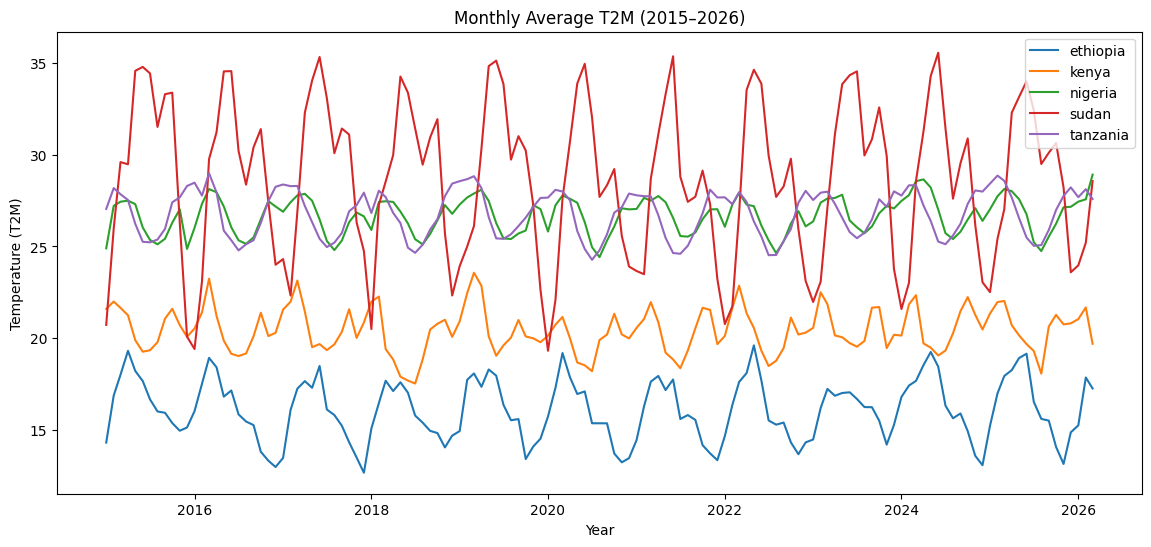

In [254]:
import matplotlib.pyplot as plt

monthly_t2m = (
    data.groupby(["country", "year", "month"])["T2M"]
    .mean()
    .reset_index()
)

monthly_t2m["date"] = pd.to_datetime(
    monthly_t2m["year"].astype(str) + "-" + monthly_t2m["month"].astype(str) + "-01"
)

plt.figure(figsize=(14,6))

for country in monthly_t2m["country"].unique():
    subset = monthly_t2m[monthly_t2m["country"] == country]
    plt.plot(subset["date"], subset["T2M"], label=country)

plt.title("Monthly Average T2M (2015–2026)")
plt.xlabel("Year")
plt.ylabel("Temperature (T2M)")
plt.legend()
plt.show()

Summary table comparing mean, median, and standard deviation of T2M across countries.

In [255]:
t2m_summary = data.groupby("country")["T2M"].agg([
    "mean", "median", "std"
]).reset_index()

print(t2m_summary)

    country       mean  median       std
0  ethiopia  16.069557   16.04  1.897073
1     kenya  20.427811   20.36  1.440936
2   nigeria  26.657275   26.82  1.123251
3     sudan  28.759878   29.16  4.681542
4  tanzania  26.802238   26.99  1.325497


This boxplot compares precipitation levels across five countries: Ethiopia, Kenya, Nigeria, Sudan, and Tanzania.

Nigeria and Tanzania show the widest spread and highest rainfall values, with many extreme outliers—indicating occasional heavy rainfall events. Ethiopia has moderate variability with some higher outliers, while Kenya and Sudan generally have lower precipitation and tighter distributions. Overall, most rainfall values cluster near the lower end across all countries, with a few significant spikes.

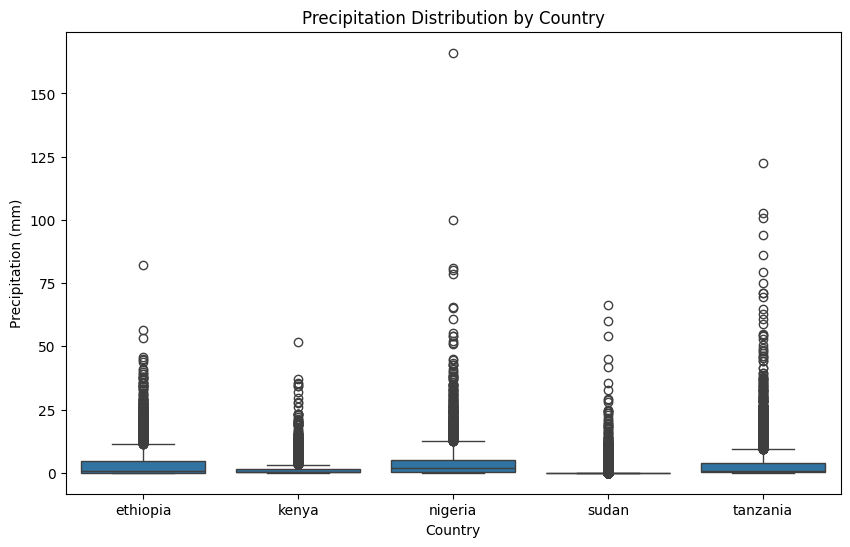

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(data=data, x="country", y="PRECTOTCORR")
plt.title("Precipitation Distribution by Country")
plt.xlabel("Country")
plt.ylabel("Precipitation (mm)")
plt.show()

Summary table comparing mean, median, and standard deviation of PRECTOTCORR across countries.

In [257]:
precip_summary = data.groupby("country")["PRECTOTCORR"].agg([
    "mean", "median", "std"
]).reset_index()

print(precip_summary)

    country      mean  median       std
0  ethiopia  3.634680    0.82  6.289571
1     kenya  1.468520    0.38  3.180533
2   nigeria  4.214940    1.84  7.267329
3     sudan  0.644032    0.00  3.058028
4  tanzania  3.739403    0.64  8.004735


Extreme Event Frequency
This Python code calculates the total frequency of two specific climate stressors for each country in the dataset.

In [258]:
heat_total = (
    data.assign(extreme_heat=data["T2M_MAX"] > 35)
    .groupby("country")["extreme_heat"]
    .sum()
    .reset_index(name="extreme_heat_days")
)

dry_total = (
    data.assign(dry_day=data["PRECTOTCORR"] < 1)
    .groupby("country")["dry_day"]
    .sum()
    .reset_index(name="dry_days")
)
print(heat_total)
print(dry_total)

    country  extreme_heat_days
0  ethiopia                  0
1     kenya                  0
2   nigeria                  0
3     sudan               2693
4  tanzania                  0
    country  dry_days
0  ethiopia      2160
1     kenya      2830
2   nigeria      1594
3     sudan      3695
4  tanzania      2303


This bar chart visualizes the Total Extreme Heat Days (exceeding 35°C) specifically for Sudan because sudan has a lot of Extreme Heat Days (exceeding 35°C)

Key Observations:
Dominant Heat Profile: Sudan recorded a massive total of approximately 2,700 days above the 35°C threshold across the observed period.

Data Variance: The black vertical line (error bar) indicates a significant range of variability, suggesting that while the average is high, there are specific years or regions within the data that fluctuate between roughly 2,200 and 3,000+ days.

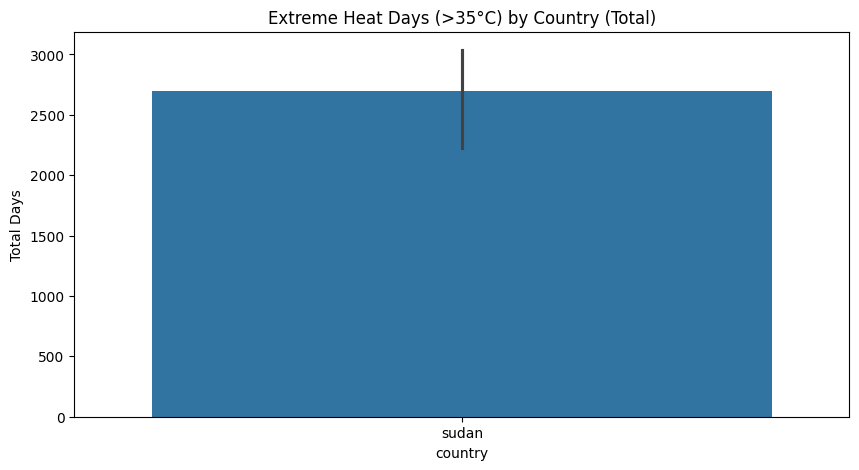

In [259]:
plt.figure(figsize=(10,5))
sns.barplot(data=heat_counts, x="country", y="extreme_heat_days", estimator=sum)
plt.title("Extreme Heat Days (>35°C) by Country (Total)")
plt.ylabel("Total Days")
plt.show()

Consecutive Dry Days (< 1 mm)

Sudan (Highest Risk): Leads significantly with nearly 3,700 total dry days. It also shows the highest variability (error bar), indicating some years are drastically more arid than others.

Nigeria (Lowest Risk): Has the fewest dry days, totaling around 1,600. This suggests a more consistent rainfall pattern or a longer wet season compared to the other nations.

Kenya & Ethiopia: Both face moderate to high aridity, with Kenya recording roughly 2,800 days and Ethiopia around 2,200 days.

Tanzania: Sits in the middle-lower tier with approximately 2,300 dry days, showing a relatively stable dry-day count with less year-to-year variance than Sudan or Kenya.

In [260]:
data["is_dry"] = data["PRECTOTCORR"] < 1

dry_counts = (
    data.groupby(["country", "year"])["is_dry"]
    .sum()
    .reset_index(name="dry_days")
)

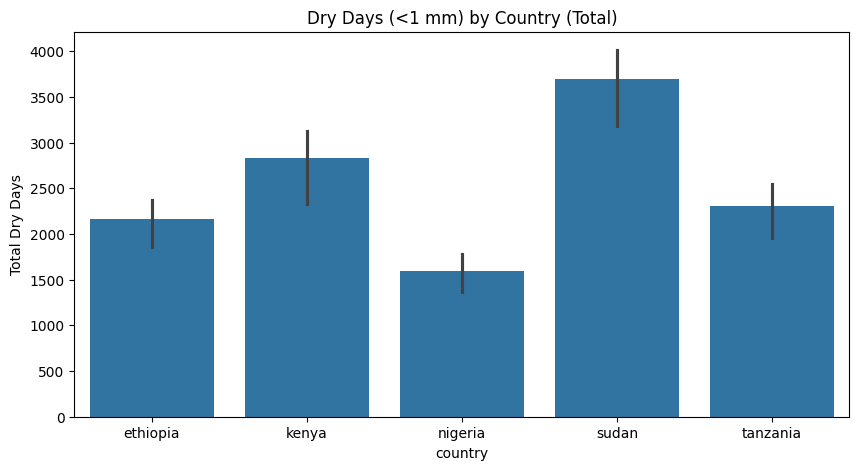

In [261]:
plt.figure(figsize=(10,5))
sns.barplot(data=dry_counts, x="country", y="dry_days", estimator=sum)
plt.title("Dry Days (<1 mm) by Country (Total)")
plt.ylabel("Total Dry Days")
plt.show()

Statistical Testing (ANOVA or Kruskal–Wallis)
ANOVA (T2M differences across countries)

In [262]:
from scipy.stats import f_oneway

groups = [
    data[data["country"] == c]["T2M"].dropna()
    for c in data["country"].unique()
]

anova_result = f_oneway(*groups)

print("ANOVA F-statistic:", anova_result.statistic)
print("p-value:", anova_result.pvalue)

ANOVA F-statistic: 18933.459542714492
p-value: 0.0


In [263]:
from scipy.stats import kruskal

kruskal_result = kruskal(*groups)

print("Kruskal statistic:", kruskal_result.statistic)
print("p-value:", kruskal_result.pvalue)

Kruskal statistic: 15389.40429787137
p-value: 0.0


ANOVA Result (p = 0): This p-value confirms that the temperature differences between these countries are statistically significant.The climatic divergence observed is not due to random chance; these nations occupy distinct thermal niches, requiring localized and specific climate adaptation policies.

In [264]:
print("Countries in final dataset:", vuln["country"].unique())

Countries in final dataset: <StringArray>
['sudan', 'tanzania', 'nigeria', 'kenya', 'ethiopia']
Length: 5, dtype: str


Climate Vulnerability Ranking

In [265]:
heat_total = heat_counts.groupby("country")["extreme_heat_days"].sum().reset_index()
dry_total = dry_counts.groupby("country")["dry_days"].sum().reset_index()

vuln = t2m_summary.merge(precip_summary, on="country", suffixes=("_temp", "_prec"))
vuln = vuln.merge(heat_total, on="country")
vuln = vuln.merge(dry_total, on="country")

In [268]:
# --- Ensure ALL countries are preserved ---
countries = data["country"].unique()

# --- Recompute extreme heat safely ---
heat_total = (
    data.assign(extreme_heat=(data["T2M_MAX"] > 35))
    .groupby("country")["extreme_heat"]
    .sum()
    .reindex(countries, fill_value=0)
    .reset_index(name="extreme_heat_days")
)

# --- Recompute dry days safely ---
dry_total = (
    data.assign(dry_day=(data["PRECTOTCORR"] < 1))
    .groupby("country")["dry_day"]
    .sum()
    .reindex(countries, fill_value=0)
    .reset_index(name="dry_days")
)

# --- Merge WITHOUT dropping countries ---
vuln = (
    t2m_summary
    .merge(precip_summary, on="country", how="outer")
    .merge(heat_total, on="country", how="outer")
    .merge(dry_total, on="country", how="outer")
)

# --- Fill missing values ---
vuln = vuln.fillna(0)

# --- Normalize + score ---
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# Use correct column names (from merged DataFrame)
cols = ["mean_x", "std_y", "extreme_heat_days", "dry_days"]

vuln_scaled = vuln.copy()
vuln_scaled[cols] = scaler.fit_transform(vuln_scaled[cols])

vuln["vulnerability_score"] = (
    vuln_scaled["mean_x"] +
    vuln_scaled["std_y"] +
    vuln_scaled["extreme_heat_days"] +
    vuln_scaled["dry_days"]
)

vuln = vuln.sort_values("vulnerability_score", ascending=False)

print(vuln[["country", "vulnerability_score"]])

    country  vulnerability_score
3     sudan             3.000000
4  tanzania             2.183196
2   nigeria             1.685244
1     kenya             0.956488
0  ethiopia             0.922667


Climate Risk Findings for COP32

Warming trends: Sudan shows the strongest overall temperature signal and ranks highest in vulnerability, suggesting a persistent and intensifying warming trend relative to the other countries. This indicates accelerating heat stress and a higher baseline climate risk.


Precipitation instability: Tanzania appears to have the most unstable precipitation patterns, reflected in its high variability score and second-place vulnerability ranking. This suggests increasing unpredictability in rainfall, which can disrupt agriculture and water systems.


Extreme heat & drought stress: Sudan stands out with the highest combined frequency of extreme heat and dry days, indicating severe and compounding climate stress. Nigeria also shows notable pressure, but not at the same intensity, pointing to a regional gradient of escalating extremes.


Ethiopia in context: Ethiopia has the lowest vulnerability score among the group, suggesting relatively more stable conditions. However, its proximity to higher-risk neighbors (Sudan and Kenya) implies growing exposure to regional climate spillovers such as drought and heatwaves.


Priority for climate finance: Ethiopia should advocate for Sudan as a top priority for climate finance at COP32. The data clearly show Sudan leading in vulnerability due to extreme heat exposure, drought frequency, and overall climate stress, making it the most urgent case for adaptation support.